In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer(as_frame=True)
df = data.frame

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.shape

(569, 31)

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
X = df.drop('target', axis=1)
y = df['target']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
columns = data.feature_names

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train = pd.DataFrame(X_train, columns=columns)

In [14]:
X_test = pd.DataFrame(X_test, columns=columns)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [16]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [17]:
logistic.fit(X_train,y_train)
gbc.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
print('Logistic Regression')

y_pred_logistic = logistic.predict(X_test)
print(accuracy_score(y_test,y_pred_logistic))
print(confusion_matrix(y_test,y_pred_logistic))
print(classification_report(y_test,y_pred_logistic))

print("-------------------------")
print('GradientBoosting Classifier')
y_pred_gbc = logistic.predict(X_test)
print(accuracy_score(y_test,y_pred_gbc))
print(confusion_matrix(y_test,y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

Logistic Regression
0.958041958041958
[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

-------------------------
GradientBoosting Classifier
0.958041958041958
[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [20]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components=4)

In [22]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [23]:
X_train_pca = pd.DataFrame(X_train_pca, columns=['PC 1', 'PC 2', 'PC 3', 'PC 4'])
X_test_pca = pd.DataFrame(X_test_pca, columns=['PC 1', 'PC 2', 'PC 3', 'PC 4'])

In [24]:
X_train_pca

,PC 1,PC 2,PC 3,PC 4
0,-0.478413,-0.480238,-0.905738,-1.388936
1,-3.476482,-2.219422,0.405915,-1.473204
2,-3.054738,-2.309091,-0.288076,-0.074841
3,1.628649,2.254628,-3.204102,-0.170868
4,1.231041,-1.899407,0.541593,2.300880
...,...,...,...,...
421,3.158756,-1.599216,0.059319,-0.434105
422,1.182785,0.278223,-3.902022,0.533188
423,3.986776,-0.321750,1.385298,-0.654037
424,-2.341799,-1.050465,-0.937970,-1.423930


In [25]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [26]:
logistic.fit(X_train_pca, y_train)
gbc.fit(X_train_pca,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [27]:
print('Logistic Regression')

y_pred_logistic = logistic.predict(X_test_pca)
print(accuracy_score(y_test,y_pred_logistic))
print(confusion_matrix(y_test,y_pred_logistic))
print(classification_report(y_test,y_pred_logistic))

print("-------------------------")
print('GradientBoosting Classifier')
y_pred_gbc = logistic.predict(X_test_pca)
print(accuracy_score(y_test,y_pred_gbc))
print(confusion_matrix(y_test,y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

Logistic Regression
0.9370629370629371
[[48  5]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143

-------------------------
GradientBoosting Classifier
0.9370629370629371
[[48  5]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



In [28]:
X = df.drop('target', axis=1)

In [29]:
scaler = StandardScaler()

In [30]:
X = scaler.fit_transform(X)

In [31]:
pca = PCA(n_components=2)

In [32]:
X = pca.fit_transform(X)

In [33]:
X = pd.DataFrame(X, columns=['PC 1', 'PC 2'])

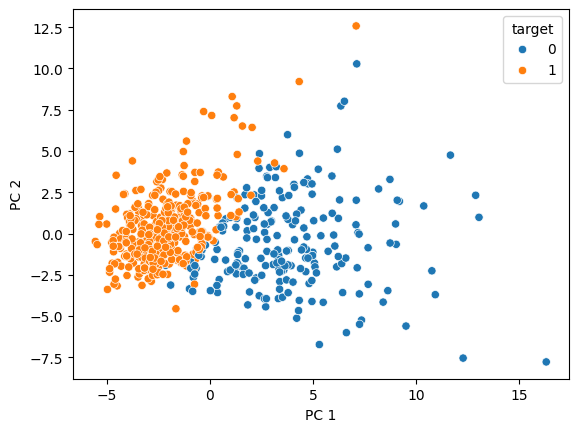

In [34]:
sns.scatterplot(data=X , x='PC 1', y='PC 2', hue=df['target'])
plt.show()